# <div align="center"> Machine Learning And Econometrics  </div>
## <div align="center"> ECO 4971/6971  </div>
#### <div align="center">Class 7 - K-Nearest Neighbors Regression</div>
<div align="center"> Jonathan Holmes, (he/him)</div>

Let's make sure you have all the required packages

In [18]:
# Data and modeling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

# Preprocessing and models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Motivating example: Advertising data

- We use the same **Advertising** dataset as in Class 6.
- Sales (response) and TV, Radio, Newspaper (predictors).
- Today we compare **linear regression** with **K-nearest neighbors (KNN) regression** for predicting sales.

In [19]:
url = "https://www.dropbox.com/scl/fi/qsw4qi1f9y67645k9po9w/Advertising.csv?rlkey=h86eg1jjgglm1cn349hvk8sa1&dl=1"
ads = pd.read_csv(url, usecols=[1,2,3,4])
display(ads.info())
ads.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


None

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


# Prediction (recap from Class 6)

- We observe a quantitative response $Y$ and predictors $X_1, X_2, \ldots, X_p$.
- General form:
$$ Y = f(\mathbf{X}) + \varepsilon $$
- **Linear regression** assumes $f$ is linear: $f(\mathbf{X}) = \beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p$.
- **K-nearest neighbors regression** does *not* assume a particular form for $f$; it estimates $f$ locally using nearby points.

# K-Nearest Neighbors (KNN) Regression

Given a value $K$ and a point $x_0$ where we want to predict $Y$:

1. Find the \( K \) training observations whose predictors are **closest** to \( x_0 \) (e.g., by Euclidean distance).
2. Estimate $\hat{f}(x_0)$ by the **average** of those $K$ observed responses.

$$ \hat{f}(x_0) = \frac{1}{K} \sum_{i \in \mathcal{N}_0} y_i $$

where $\mathcal{N}_0$ is the set of indices of the $K$ nearest neighbors of $x_0$.

# KNN vs Linear Regression

| | Linear regression | KNN regression |
|---|-------------------|----------------|
| **Form of $f$** | Global linear | Local average (flexible) |
| **Interpretation** | Coefficients = marginal effects | No simple coefficients |
| **When it works well** | True relationship ~ linear | Nonlinear, local structure |
| **Choice** | Which predictors | $K$ (smoothing) |

- Small $K$: more flexible, noisier (high variance).
- Large $K$: smoother, can miss curvature (higher bias).

# Train/test split

- To compare models fairly we use a **train/test split**: fit on training data, evaluate on held-out test data.
- For KNN, **scale** the features so distance is not dominated by one variable (e.g., TV in dollars vs Radio in dollars).

In [20]:
# Predictors and response
X = ads[['TV', 'Radio', 'Newspaper']]
y = ads['Sales']

# Train/test split (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (fit on train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", len(y_train), "  Test size:", len(y_test))

Train size: 160   Test size: 40


# Fit both models

- **Linear regression**: fit on training data (no scaling required for interpretation, but we use same train/test for fairness).
- **KNN regression**: fit on *scaled* training data; we choose $K = 5$ for illustration.

In [21]:
# Linear regression
lm = LinearRegression()
lm.fit(X_train, y_train)

# KNN regression (K=5)
knn5 = KNeighborsRegressor(n_neighbors=5)
knn5.fit(X_train_scaled, y_train)

print("Models fitted on training data.")

Models fitted on training data.


# Compare predictions on the test set

- Predict with both models on the **test** set.
- Use **MSE** (mean squared error) and **R²** to compare.
  - Lower MSE is better.
  - Higher R² is better (fraction of variance explained).

In [22]:
# Predictions (linear uses unscaled X_test; KNN uses scaled)
y_pred_lm = lm.predict(X_test)
y_pred_knn = knn5.predict(X_test_scaled)

# Test MSE and R²
print("Linear regression (test):")
print(f"  MSE = {mean_squared_error(y_test, y_pred_lm):.4f}")
print(f"  R²  = {r2_score(y_test, y_pred_lm):.4f}")
print()
print("KNN regression, K=5 (test):")
print(f"  MSE = {mean_squared_error(y_test, y_pred_knn):.4f}")
print(f"  R²  = {r2_score(y_test, y_pred_knn):.4f}")

Linear regression (test):
  MSE = 3.1741
  R²  = 0.8994

KNN regression, K=5 (test):
  MSE = 2.2074
  R²  = 0.9301


# Visual comparison: Sales vs TV (simple case)

- Use only **TV** as the predictor so we can plot fitted curves in 2D.
- Compare the linear fit vs the KNN fit (step-like or smooth depending on $K$).

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


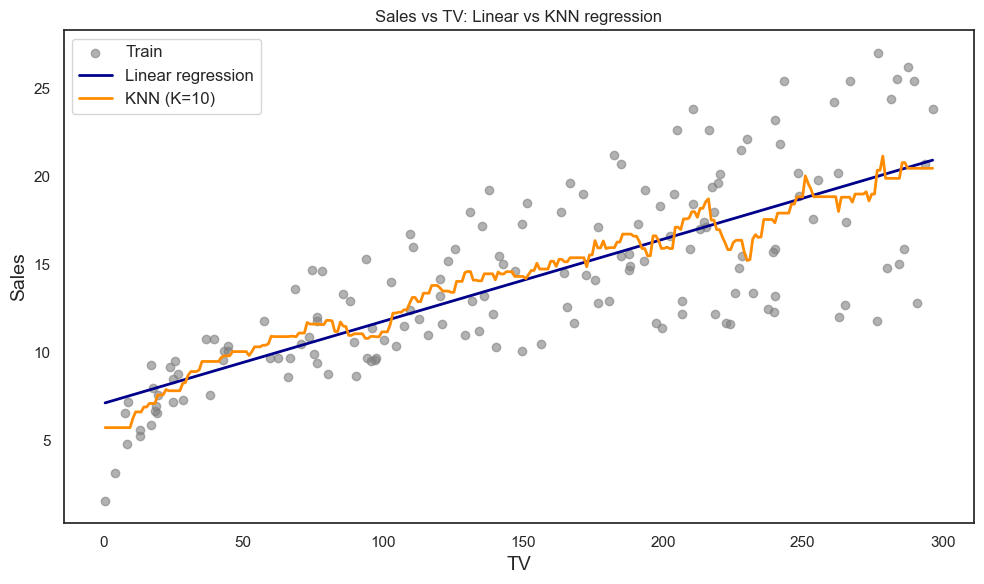

In [23]:
# Single predictor: TV
X_tv = ads[['TV']]
y_tv = ads['Sales']
X_tv_train, X_tv_test, y_tv_train, y_tv_test = train_test_split(X_tv, y_tv, test_size=0.2, random_state=42)

scaler_tv = StandardScaler()
X_tv_train_s = scaler_tv.fit_transform(X_tv_train)
X_tv_test_s = scaler_tv.transform(X_tv_test)

lm_tv = LinearRegression().fit(X_tv_train, y_tv_train)
knn_tv = KNeighborsRegressor(n_neighbors=10).fit(X_tv_train_s, y_tv_train)

# Grid for smooth curves
tv_grid = np.linspace(X_tv.TV.min(), X_tv.TV.max(), 300).reshape(-1, 1)
tv_grid_s = scaler_tv.transform(tv_grid)

pred_lm_grid = lm_tv.predict(tv_grid)
pred_knn_grid = knn_tv.predict(tv_grid_s)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.scatter(X_tv_train, y_tv_train, color='gray', alpha=0.6, label='Train')
ax.plot(tv_grid, pred_lm_grid, color='darkblue', lw=2, label='Linear regression')
ax.plot(tv_grid, pred_knn_grid, color='darkorange', lw=2, label='KNN (K=10)')
ax.set_xlabel('TV', fontsize=14)
ax.set_ylabel('Sales', fontsize=14)
ax.legend(fontsize=12)
ax.set_title('Sales vs TV: Linear vs KNN regression')
plt.tight_layout()
plt.show()

# When the number of predictors increases (from 1 to many)

- With **one predictor**, "nearest" is clear: we order points by distance along that single axis and average the $Y$ values of the $K$ closest points.
- With **multiple predictors** ($p > 1$), we need a notion of distance in $p$-dimensional space. KNN typically uses **Euclidean distance**: for two points $x$ and $x'$, $d(x, x') = \sqrt{\sum_{j=1}^p (x_j - x'_j)^2}$.
- So we find the $K$ training points whose *vector* of predictors is closest to the new point, then average their $Y$ values.
- Adding more predictors changes which points count as "neighbors": distance is computed over more coordinates, so the set of nearest neighbors can look very different from the single-predictor case.

In [24]:
# Demo: 1 predictor (TV only) vs 2 predictors (TV + Radio)
# Same train/test split for a fair comparison
X_1 = X_train[['TV']].values
X_2 = X_train[['TV', 'Radio']].values
X_1_test = X_test[['TV']].values
X_2_test = X_test[['TV', 'Radio']].values
# Scale the 2-predictor case so distance is comparable across axes
scaler_2 = StandardScaler()
X_2_s = scaler_2.fit_transform(X_2)
X_2_test_s = scaler_2.transform(X_2_test)

knn_1 = KNeighborsRegressor(n_neighbors=10).fit(X_1, y_train)
knn_2 = KNeighborsRegressor(n_neighbors=10).fit(X_2_s, y_train)

mse_1 = mean_squared_error(y_test, knn_1.predict(X_1_test))
mse_2 = mean_squared_error(y_test, knn_2.predict(X_2_test_s))
print("KNN with 1 predictor (TV only)  — Test MSE:", round(mse_1, 4))
print("KNN with 2 predictors (TV+Radio, scaled) — Test MSE:", round(mse_2, 4))
print("Adding Radio (and scaling) changes which points are 'nearest' and can improve or change the fit.")

KNN with 1 predictor (TV only)  — Test MSE: 9.7107
KNN with 2 predictors (TV+Radio, scaled) — Test MSE: 1.4915
Adding Radio (and scaling) changes which points are 'nearest' and can improve or change the fit.


# Why scaling matters in KNN

- KNN relies entirely on **distance** between points. If one predictor is on a much larger scale than another (e.g. TV budget in thousands vs Radio in tens), that predictor will **dominate** the distance.
- Example: TV ranges 0–300, Radio 0–50. A difference of 10 in TV contributes $10^2 = 100$ to squared distance, while a difference of 10 in Radio also contributes 100. So a "big" change in Radio (e.g. 0 vs 50) has the same impact as a "small" change in TV (e.g. 250 vs 300). The model then effectively treats TV as more important than intended.
- **Scaling** (e.g. subtract mean, divide by standard deviation) puts predictors on a comparable scale so each contributes to distance in a balanced way. We **fit** the scaler on the training set and **transform** both training and test data.

In [25]:
# How StandardScaler works: z = (x - mean) / std
# Fit on training data to get the mean and std of each column
X_tr = X_train[['TV', 'Radio']].values
scaler_demo = StandardScaler()
scaler_demo.fit(X_tr)
print("StandardScaler formula: z = (x - mean) / std")
print("Fitted on training data:")
print("  Means (TV, Radio):", scaler_demo.mean_)
print("  Std devs (TV, Radio):", scaler_demo.scale_)
print("\nBefore scaling (first 5 rows):")
print(X_tr[:5])
print("\nAfter scaling (first 5 rows):")
scaled = scaler_demo.transform(X_tr[:5])
print(scaled)
# On the full training set, scaled columns have mean 0 and std 1
full_scaled = scaler_demo.transform(X_tr)
print("\nOn the full training set, scaled columns have mean ≈ 0, std ≈ 1:")
print("  Means:", full_scaled.mean(axis=0).round(6))
print("  Std devs:", full_scaled.std(axis=0).round(6))

StandardScaler formula: z = (x - mean) / std
Fitted on training data:
  Means (TV, Radio): [150.019375  22.875625]
  Std devs (TV, Radio): [84.15463408 14.75887761]

Before scaling (first 5 rows):
[[116.    7.7]
 [177.    9.3]
 [ 43.1  26.7]
 [ 62.3  12.6]
 [224.    2.4]]

After scaling (first 5 rows):
[[-0.40424839 -1.02823707]
 [ 0.32060772 -0.91982774]
 [-1.27051084  0.2591237 ]
 [-1.04235941 -0.6962335 ]
 [ 0.8791034  -1.38734296]]

On the full training set, scaled columns have mean ≈ 0, std ≈ 1:
  Means: [-0. -0.]
  Std devs: [1. 1.]


In [ ]:
# Demo: Unscaled vs scaled (TV + Radio)
# Unscaled: raw TV and Radio (TV on 0–300 scale dominates)
X_tr_raw = X_train[['TV', 'Radio']].values
X_te_raw = X_test[['TV', 'Radio']].values
knn_raw = KNeighborsRegressor(n_neighbors=10).fit(X_tr_raw, y_train)
mse_raw = mean_squared_error(y_test, knn_raw.predict(X_te_raw))

# Scaled: fit scaler on train, transform train and test
scaler_tr = StandardScaler()
X_tr_sc = scaler_tr.fit_transform(X_tr_raw)
X_te_sc = scaler_tr.transform(X_te_raw)
knn_sc = KNeighborsRegressor(n_neighbors=10).fit(X_tr_sc, y_train)
mse_sc = mean_squared_error(y_test, knn_sc.predict(X_te_sc))

print("KNN with TV + Radio (unscaled) — Test MSE:", round(mse_raw, 4))
print("KNN with TV + Radio (scaled)   — Test MSE:", round(mse_sc, 4))
print("Scaling puts TV and Radio on a comparable scale - it changes which points are 'nearest'.")

KNN with TV + Radio (unscaled) — Test MSE: 1.6624
KNN with TV + Radio (scaled)   — Test MSE: 1.4915
Scaling puts TV and Radio on a comparable scale so distance is not dominated by TV.


# The curse of dimensionality

- In **high dimensions** (many predictors $p$), points tend to be far apart: the volume of the space grows quickly with $p$, so a fixed number of observations becomes sparse.
- As a result, the "nearest" neighbors in high dimensions are often **not very near** in absolute terms; the local average is then taken over points that may be quite different from $x_0$, so the estimate $\hat{f}(x_0)$ can be poor.
- To keep a given density of data (and thus meaningful "neighborhoods"), the **sample size needed grows rapidly** with $p$—this is the **curse of dimensionality**. KNN can still be used with many predictors, but performance often degrades unless $n$ is large relative to $p$, or we reduce dimension / use only relevant predictors.

In [27]:
# Demo: Test MSE as we add predictors (TV -> TV+Radio -> TV+Radio+Newspaper)
# All features scaled; same K and same train/test split
K = 10
results = []
for cols in [['TV'], ['TV', 'Radio'], ['TV', 'Radio', 'Newspaper']]:
    X_tr = X_train[cols].values
    X_te = X_test[cols].values
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    knn = KNeighborsRegressor(n_neighbors=K).fit(X_tr_s, y_train)
    mse = mean_squared_error(y_test, knn.predict(X_te_s))
    results.append((len(cols), cols, mse))
print("Predictors used          Test MSE")
for p, names, mse in results:
    print(f"  p={p} {str(names):35s} {mse:.4f}")
print("With more dimensions, 'nearest' neighbors are often farther away; performance may worsen unless n is large.")

Predictors used          Test MSE
  p=1 ['TV']                              9.7107
  p=2 ['TV', 'Radio']                     1.4915
  p=3 ['TV', 'Radio', 'Newspaper']        2.7341
With more dimensions, 'nearest' neighbors are often farther away; performance may worsen unless n is large.


# Choosing $K$

- $K$ controls the **bias–variance trade-off**.
- Small $K$: low bias, high variance (fits training data closely, can overfit).
- Large $K$: higher bias, lower variance (smoother, can underfit).
- In practice: use **validation** or **cross-validation** to pick $K$ (e.g., minimize test or CV MSE).

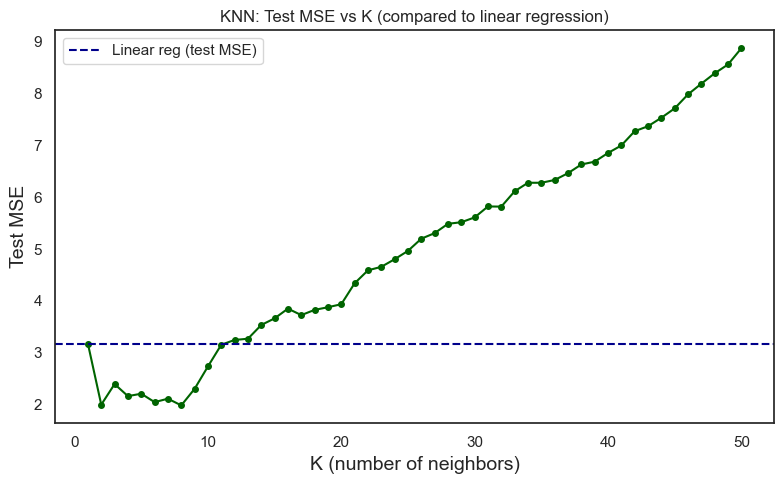

In [28]:
# Test MSE for different $K$ (using full 3-predictor setup)
k_values = range(1, 51)
test_mse_knn = []
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    test_mse_knn.append(mean_squared_error(y_test, pred))

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(k_values, test_mse_knn, 'o-', color='darkgreen', markersize=4)
ax.axhline(mean_squared_error(y_test, y_pred_lm), color='darkblue', linestyle='--', label='Linear reg (test MSE)')
ax.set_xlabel('K (number of neighbors)', fontsize=14)
ax.set_ylabel('Test MSE', fontsize=14)
ax.legend()
ax.set_title('KNN: Test MSE vs K (compared to linear regression)')
plt.tight_layout()
plt.show()

# In-Class Exercise

**Question 1.** In the "1 predictor vs 2 predictors" demo we compared KNN with TV only vs TV + Radio (scaled). Why do we scale when using more than one predictor? What would go wrong if we did not scale?

**Question 2.** In the "Unscaled vs scaled" demo, KNN with scaled TV + Radio had lower test MSE than with unscaled. In one sentence, what is the main reason scaling helped?

**Question 3.** In the "curse of dimensionality" demo we saw test MSE for $p=1$, $p=2$, and $p=3$ predictors. In this sample, did adding the third predictor (Newspaper) improve or worsen test MSE? How does that relate to the idea of the curse of dimensionality?

**Question 4.** When would you prefer **linear regression** over **KNN regression** for predicting a quantitative response? When might you prefer KNN? (1–2 sentences each.)